# AdaBoost: Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. The math behind AdaBoost (SAMME algorithm, sample weight updates, exponential loss)
2. Worked examples using actual HMEQ data
3. Model training with hyperparameter tuning
4. Diagnostic visualizations (exported as interactive plotly HTML)
5. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

# Additional imports
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import ast

MODEL_NAME = "AdaBoost"
MODEL_SLUG = "adaboost"

# Load data
(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind AdaBoost

### 2.1 The Core Idea

AdaBoost is the original boosting algorithm, introduced by Freund and Schapire (1997). Unlike Random Forest which trains trees independently and averages their predictions, AdaBoost trains trees **sequentially** where each new tree focuses on examples that previous trees got wrong.

The key insight: instead of training each weak learner on the same data, **reweight the training data** after each iteration. Misclassified examples get higher weights, so the next learner pays more attention to them.

### 2.2 The SAMME Algorithm (Discrete AdaBoost)

AdaBoost has many variants. We use **SAMME** (Stagewise Additive Modeling using Multiclass Exponential loss), which is the discrete version sklearn uses for multiclass problems.

#### Stage 1: Initialize Sample Weights

$$w_i^{(1)} = \frac{1}{n} \quad \text{for all } i = 1, \ldots, n$$

Start with equal weight on all samples.

#### Stage t: Train Weak Learner with Current Weights

1. **Train** base classifier $h_t$ on training data with weights $w_i^{(t)}$
2. **Compute** weighted error rate:

$$\text{err}_t = \sum_{i=1}^{n} w_i^{(t)} \cdot \mathbb{1}[h_t(x_i) \neq y_i]$$

3. **Compute** estimator weight:

$$\alpha_t = \frac{1}{2} \ln \left( \frac{1 - \text{err}_t}{\text{err}_t} \right)$$

This is the **exponential weight formula**. Key properties:
- If $\text{err}_t = 0.5$ (random guessing), then $\alpha_t = 0$ (this classifier is worthless, give it zero weight)
- If $\text{err}_t < 0.5$ (better than random), then $\alpha_t > 0$ (positive weight)
- If $\text{err}_t$ is very small (near perfect), then $\alpha_t$ is very large (heavily weighted)
- The formula is symmetric: $\text{err}_t = 0.3 \Rightarrow \alpha_t \approx 0.42$, $\text{err}_t = 0.7 \Rightarrow \alpha_t \approx -0.42$

4. **Update** sample weights:

$$w_i^{(t+1)} = w_i^{(t)} \cdot \exp\left( -\alpha_t \cdot y_i' \cdot h_t(x_i) \right)$$

where $y_i' \in \{-1, +1\}$ (convert from $\{0, 1\}$) and $h_t(x_i) \in \{-1, +1\}$.

In practice, this simplifies to:
- If $h_t(x_i) = y_i$ (correct): $w_i^{(t+1)} = w_i^{(t)} \cdot e^{-\alpha_t}$ (decrease weight)
- If $h_t(x_i) \neq y_i$ (incorrect): $w_i^{(t+1)} = w_i^{(t)} \cdot e^{+\alpha_t}$ (increase weight)

5. **Renormalize** weights to sum to 1:

$$w_i^{(t+1)} \leftarrow \frac{w_i^{(t+1)}}{\sum_{j=1}^{n} w_j^{(t+1)}}$$

#### Final Prediction: Weighted Majority Vote

The final classifier is a weighted combination of all $T$ weak learners:

$$\hat{y} = \text{sign}\left( \sum_{t=1}^{T} \alpha_t \cdot h_t(x) \right)$$

For probability estimates, apply sigmoid:

$$P(y=1 | x) = \frac{1}{1 + \exp\left(-2 \sum_{t=1}^{T} \alpha_t \cdot h_t(x) \right)}$$

### 2.3 Exponential Loss Minimization

AdaBoost is equivalently solving:

$$\min_{\alpha_1, \ldots, \alpha_T} \sum_{i=1}^{n} \exp\left( -y_i' \sum_{t=1}^{T} \alpha_t h_t(x_i) \right)$$

This is the **exponential loss** function. It is very sensitive to misclassifications (exponential penalty), which makes AdaBoost focus heavily on hard examples. This is a key difference from gradient boosting (which uses other loss functions like log loss or squared error).

### 2.4 Why Use Decision Stumps?

Our code uses `DecisionTreeClassifier(max_depth=1)` as the base learner. This creates **decision stumps** (single-level trees, just one split). Why?

1. **Weak learners are faster**: Stumps train in milliseconds
2. **Ensemble diversity**: Different stumps create more diverse errors, which boosting can correct
3. **Overfitting control**: The ensemble effect prevents memorization better than single weak learners
4. **Proven effective**: The original Freund-Schapire paper used stumps and showed ~10-50 stumps often outperform a single deep tree

You could use deeper trees (e.g., `max_depth=5`) as base learners, trading off training time for higher per-tree performance (but less ensemble benefit).

### 2.5 Learning Rate

The `learning_rate` parameter (default 1.0) shrinks the estimator weights:

$$\alpha_t \leftarrow \text{learning_rate} \times \alpha_t$$

A smaller learning_rate like 0.1 or 0.5 requires more iterations to fit the data but often generalizes better (bias-variance tradeoff). This is **regularization through shrinkage**.

---
## 3. Visualizing Exponential Loss and Weight Updates

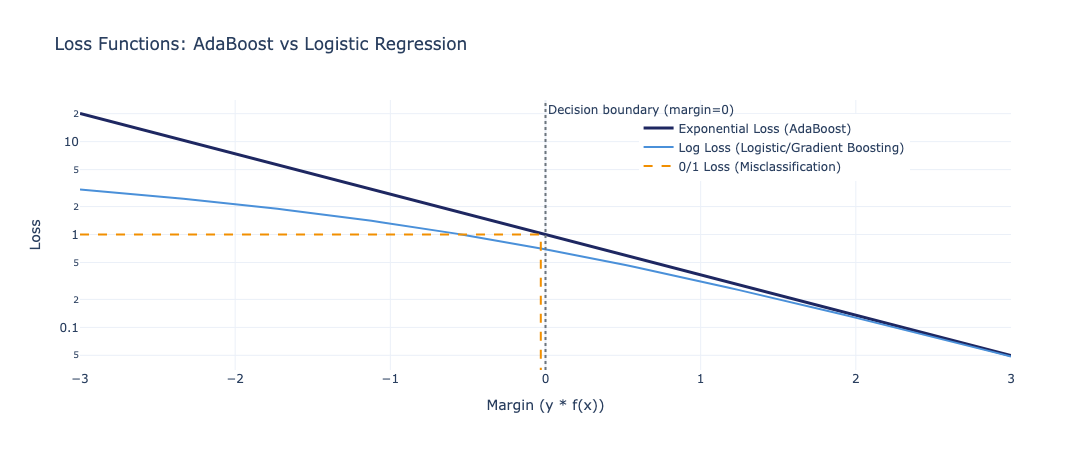

  Saved: outputs/adaboost/loss_function_comparison.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/adaboost/loss_function_comparison.html')

In [2]:
# Show how exponential loss grows with margin
margin = np.linspace(-3, 3, 100)
exp_loss = np.exp(-margin)
log_loss = np.log(1 + np.exp(-margin))  # Logistic regression loss for comparison
zero_one_loss = (margin <= 0).astype(float)  # 0/1 loss for comparison

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=margin, y=exp_loss, name="Exponential Loss (AdaBoost)",
    line=dict(color=COLORS["navy"], width=3),
))
fig.add_trace(go.Scatter(
    x=margin, y=log_loss, name="Log Loss (Logistic/Gradient Boosting)",
    line=dict(color=COLORS["accent"], width=2),
))
fig.add_trace(go.Scatter(
    x=margin, y=zero_one_loss, name="0/1 Loss (Misclassification)",
    line=dict(color=COLORS["orange"], width=2, dash="dash"),
))
fig.add_vline(x=0, line_dash="dot", line_color=COLORS["gray"],
              annotation_text="Decision boundary (margin=0)")
fig.update_layout(
    title="Loss Functions: AdaBoost vs Logistic Regression",
    xaxis_title="Margin (y * f(x))",
    yaxis_title="Loss",
    yaxis_type="log",
    height=450, width=700,
    legend=dict(x=0.6, y=0.95),
)
fig.show()
save_chart(fig, MODEL_SLUG, "loss_function_comparison")

---
## 4. Worked Example: Manual Weight Updates

Let's manually walk through the first few iterations of AdaBoost on HMEQ data to see how weights evolve.

In [3]:
# Demonstrate weight updates
examples = get_example_rows(df, n=3)
for idx, row in examples.iterrows():
    print_example_row(row, idx)

print("\n" + "="*70)
print("WORKED EXAMPLE: AdaBoost Weight Updates (First 3 Iterations)")
print("="*70)

# Train a simple 3-stump AdaBoost to show the weight dynamics
ada_simple = Pipeline([
    ("prep", prep_tree),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
        n_estimators=3,
        learning_rate=1.0,
        algorithm="SAMME",
        random_state=RANDOM_STATE,
    )),
])
ada_simple.fit(X_train, y_train)

ada_clf = ada_simple.named_steps["clf"]
X_train_prep = ada_simple.named_steps["prep"].fit_transform(X_train)

print(f"\nInitial Setup:")
print(f"  Total training samples: {len(X_train)}")
print(f"  Good loans: {(y_train == 0).sum()} ({(y_train == 0).mean():.1%})")
print(f"  Defaults: {(y_train == 1).sum()} ({(y_train == 1).mean():.1%})")
print(f"  Initial weight per sample: 1/{len(X_train)} = {1.0/len(X_train):.6f}")

for t in range(min(3, ada_clf.n_estimators)):
    h_t = ada_clf.estimators_[t]
    alpha_t = ada_clf.estimator_weights_[t]
    
    y_pred_t = h_t.predict(X_train_prep)
    errors = (y_pred_t != y_train.values)
    n_errors = errors.sum()
    
    # Compute error rate (using uniform weights for this demo)
    err_t = n_errors / len(X_train)
    
    print(f"\n--- Iteration {t+1} ---")
    print(f"  Weak learner: {h_t.get_depth()}-level tree (stump)")
    print(f"  Misclassifications: {n_errors} out of {len(X_train)} ({err_t:.4f})")
    print(f"  Estimator weight: α_{t+1} = {alpha_t:.4f}")
    print(f"  Formula: α = 0.5 * ln((1 - err) / err)")
    print(f"          = 0.5 * ln((1 - {err_t:.4f}) / {err_t:.4f})")
    print(f"          = {alpha_t:.4f}")
    print(f"")
    print(f"  Sample weight update rule:")
    print(f"    - If correctly classified: w_i *= exp(-{alpha_t:.4f}) = {np.exp(-alpha_t):.4f}")
    print(f"    - If misclassified:       w_i *= exp(+{alpha_t:.4f}) = {np.exp(+alpha_t):.4f}")
    print(f"  ")
    print(f"  Result: Misclassified samples get {np.exp(alpha_t)/np.exp(-alpha_t):.1f}x more weight")

print(f"\n" + "="*70)
print(f"\nFinal Ensemble Prediction (for a single borrower):")
print(f"  Combine {ada_clf.n_estimators} stump predictions with their weights")
print(f"  f(x) = Σ α_t * h_t(x)")
print(f"  P(default | x) = sigmoid(2 * f(x))")


--- Example Borrower 1 (Actual: GOOD) ---
  LOAN           : 10600
  MORTDUE        : 82365.0
  VALUE          : 100272.0
  REASON         : DebtCon
  JOB            : ProfExe
  YOJ            : 3.0
  DEROG          : 1.0
  DELINQ         : 0.0
  CLAGE          : 122.48359427
  NINQ           : 0.0
  CLNO           : 26.0
  DEBTINC        : 33.651646949

--- Example Borrower 2 (Actual: GOOD) ---
  LOAN           : 24800
  MORTDUE        : 82670.0
  VALUE          : 106563.0
  REASON         : DebtCon
  JOB            : Mgr
  YOJ            : 8.0
  DEROG          : 0.0
  DELINQ         : 0.0
  CLAGE          : 302.98443202
  NINQ           : 2.0
  CLNO           : 28.0
  DEBTINC        : 30.956485836

--- Example Borrower 3 (Actual: DEFAULT) ---
  LOAN           : 9900
  MORTDUE        : 71371.0
  VALUE          : 84865.0
  REASON         : DebtCon
  JOB            : Mgr
  YOJ            : 0.0
  DEROG          : 2.0
  DELINQ         : 0.0
  CLAGE          : 94.805235749
  NINQ         

---
## 5. Model Training with Hyperparameter Tuning

In [4]:
# Hyperparameter grid
param_grid = {
    "clf__n_estimators": [10, 30, 50, 100, 200],
    "clf__learning_rate": [0.5, 1.0, 1.5],
    "clf__estimator__max_depth": [1, 2, 3],
}

ada_pipe = Pipeline([
    ("prep", prep_tree),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        algorithm="SAMME",
        random_state=RANDOM_STATE,
    )),
])

grid = GridSearchCV(
    ada_pipe, param_grid, cv=cv,
    scoring="recall", n_jobs=-1, refit=True,
)
grid.fit(X_train, y_train)

best_ada = grid.best_estimator_
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV recall: {grid.best_score_:.4f}")

ada_clf = best_ada.named_steps["clf"]
print(f"\nBest model:")
print(f"  N estimators: {ada_clf.n_estimators}")
print(f"  Learning rate: {ada_clf.learning_rate}")
print(f"  Base estimator: {ada_clf.estimator}")

/usr/local/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 a

Best parameters: {'clf__estimator__max_depth': 3, 'clf__learning_rate': 1.5, 'clf__n_estimators': 200}
Best CV recall: 0.7254

Best model:
  N estimators: 200
  Learning rate: 1.5
  Base estimator: DecisionTreeClassifier(max_depth=3, random_state=42)


---
## 6. Model Evaluation

In [5]:
# Cross-validation score
cv_scores = cross_val_score(best_ada, X_train, y_train, cv=cv, scoring="recall")
cv_mean = cv_scores.mean()
print(f"CV Recall scores: {cv_scores}")
print(f"CV Recall mean: {cv_mean:.4f} (+/- {cv_scores.std():.4f})")

# Test set evaluation
metrics, y_pred, y_score = evaluate_model(MODEL_NAME, best_ada, X_test, y_test, cv_mean)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))

CV Recall scores: [0.73033708 0.71910112 0.78651685 0.68156425 0.70949721]
CV Recall mean: 0.7254 (+/- 0.0346)

  AdaBoost
  Recall: 0.6734  |  Precision: 0.8621  |  F1: 0.7561
  AUC: 0.9466  |  PR-AUC: 0.8755
  Confusion: TP=200 FP=32 FN=97 TN=1161

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.92      0.97      0.95      1193
     Default       0.86      0.67      0.76       297

    accuracy                           0.91      1490
   macro avg       0.89      0.82      0.85      1490
weighted avg       0.91      0.91      0.91      1490



---
## 7. Estimator Weights Over Iterations

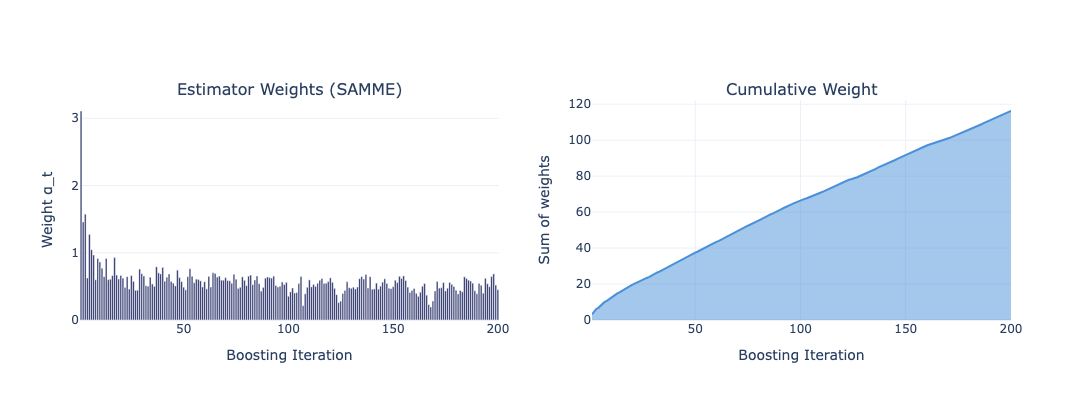

  Saved: outputs/adaboost/estimator_weights_curve.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/adaboost/estimator_weights_curve.html')

In [6]:
# Plot how estimator weights evolve with iterations
df_weights = pd.DataFrame({
    "iteration": list(range(1, len(ada_clf.estimator_weights_) + 1)),
    "weight": ada_clf.estimator_weights_,
    "cumulative": np.cumsum(ada_clf.estimator_weights_),
})

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Estimator Weights (SAMME)", "Cumulative Weight"),
)

fig.add_trace(
    go.Bar(x=df_weights["iteration"], y=df_weights["weight"],
           marker_color=COLORS["navy"], name="Weight per estimator"),
    row=1, col=1,
)

fig.add_trace(
    go.Scatter(x=df_weights["iteration"], y=df_weights["cumulative"],
               line=dict(color=COLORS["accent"], width=2),
               fill="tozeroy", name="Cumulative weight"),
    row=1, col=2,
)

fig.update_xaxes(title_text="Boosting Iteration", row=1, col=1)
fig.update_xaxes(title_text="Boosting Iteration", row=1, col=2)
fig.update_yaxes(title_text="Weight α_t", row=1, col=1)
fig.update_yaxes(title_text="Sum of weights", row=1, col=2)

fig.update_layout(height=400, width=900, showlegend=False)
fig.show()
save_chart(fig, MODEL_SLUG, "estimator_weights_curve")

---
## 8. Staged Prediction: Performance vs Number of Estimators

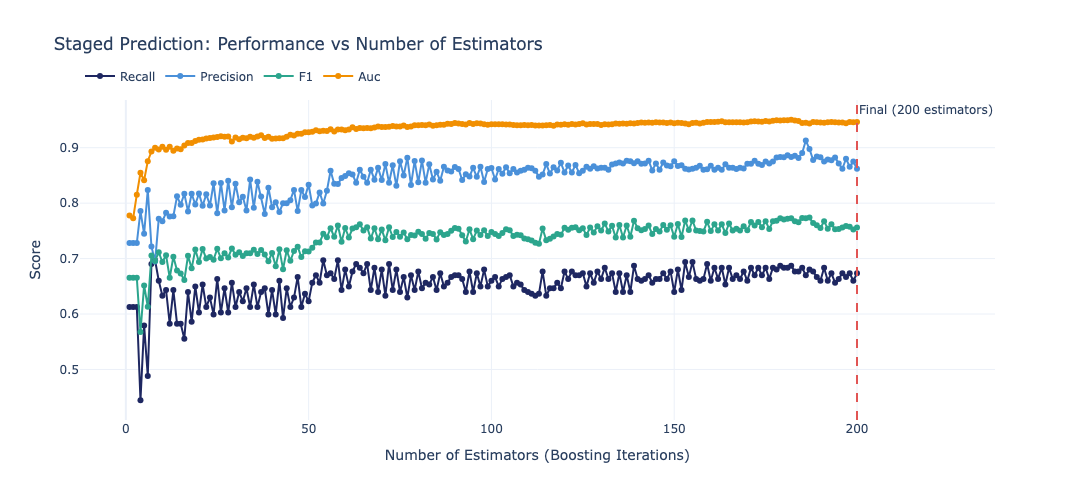

  Saved: outputs/adaboost/staged_predictions.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/adaboost/staged_predictions.html')

In [8]:
# Transform X_test through the preprocessing pipeline
preprocessor = best_ada.named_steps["prep"]
X_test_prep = preprocessor.transform(X_test)

ada_clf = best_ada.named_steps["clf"]

# Use staged_predict and staged_predict_proba on preprocessed data
staged_results = []
staged_proba_gen = ada_clf.staged_predict_proba(X_test_prep)
for i, y_pred_stage in enumerate(ada_clf.staged_predict(X_test_prep), 1):
    y_score_stage = next(staged_proba_gen)[:, 1]
    recall = recall_score(y_test, y_pred_stage)
    precision = precision_score(y_test, y_pred_stage, zero_division=0)
    f1 = f1_score(y_test, y_pred_stage)
    auc = roc_auc_score(y_test, y_score_stage)

    staged_results.append({
        "n_estimators": i,
        "recall": recall,
        "precision": precision,
        "f1": f1,
        "auc": auc,
    })

df_staged = pd.DataFrame(staged_results)
fig_staged = go.Figure()
for metric, color in [("recall", COLORS["navy"]), ("precision", COLORS["accent"]),
                       ("f1", COLORS["green"]), ("auc", COLORS["orange"])]:
    fig_staged.add_trace(go.Scatter(
        x=df_staged["n_estimators"], y=df_staged[metric],
        name=metric.capitalize(),
        line=dict(color=color, width=2),
        mode="lines+markers",
    ))
fig_staged.add_vline(x=ada_clf.n_estimators, line_dash="dash", line_color=COLORS["red"],
                      annotation_text=f"Final ({ada_clf.n_estimators} estimators)")
fig_staged.update_layout(
    title="Staged Prediction: Performance vs Number of Estimators",
    xaxis_title="Number of Estimators (Boosting Iterations)",
    yaxis_title="Score",
    height=500, width=750,
    legend=dict(orientation="h", y=1.12),
)
fig_staged.show()
save_chart(fig_staged, MODEL_SLUG, "staged_predictions")

---
## 9. Feature Importance (Sklearn MDI)

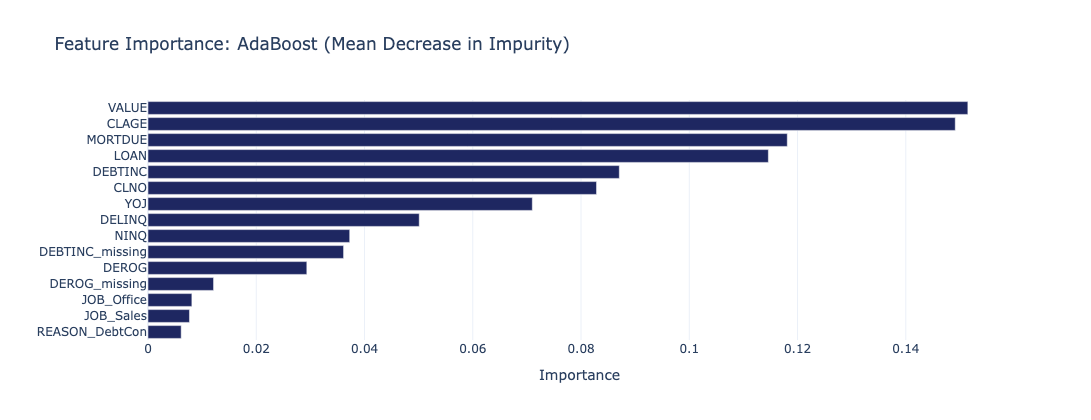

  Saved: outputs/adaboost/feature_importance.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/adaboost/feature_importance.html')

In [9]:
# Get feature names after preprocessing
preprocessor = best_ada.named_steps["prep"]
cat_encoder = preprocessor.named_transformers_["cat"]
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

# Feature importance
importances = ada_clf.feature_importances_

fig_imp = plot_feature_importance(importances, all_feature_names, MODEL_NAME, "Mean Decrease in Impurity")
fig_imp.show()
save_chart(fig_imp, MODEL_SLUG, "feature_importance")

---
## 10. Learning Rate Sensitivity

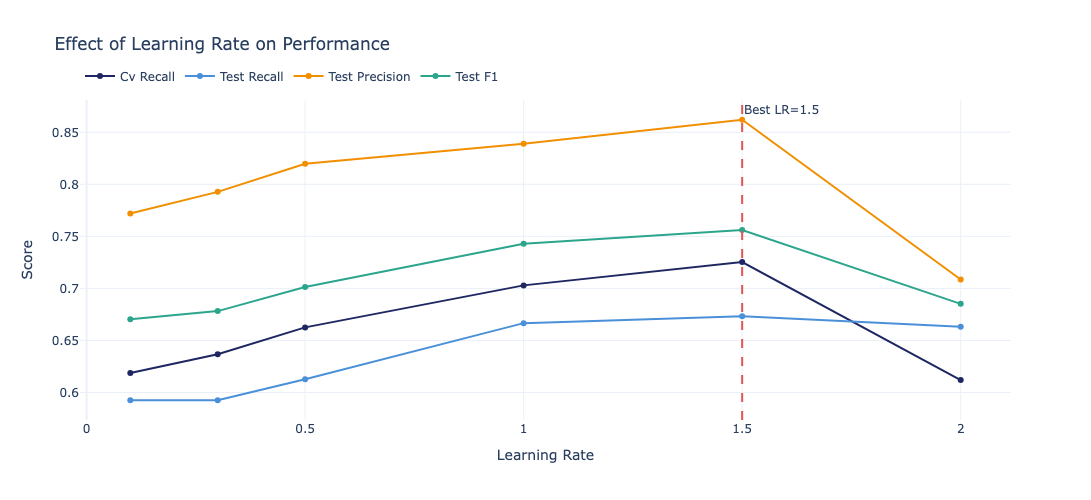

  Saved: outputs/adaboost/learning_rate_sensitivity.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/adaboost/learning_rate_sensitivity.html')

In [10]:
# Sweep learning rate with fixed n_estimators
learning_rates = [0.1, 0.3, 0.5, 1.0, 1.5, 2.0]
lr_results = []

best_n_est = best_ada.named_steps["clf"].n_estimators
best_base_depth = best_ada.named_steps["clf"].estimator.max_depth

for lr in learning_rates:
    ada_temp = Pipeline([
        ("prep", prep_tree),
        ("clf", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=best_base_depth, random_state=RANDOM_STATE),
            n_estimators=best_n_est,
            learning_rate=lr,
            algorithm="SAMME",
            random_state=RANDOM_STATE,
        )),
    ])
    
    # CV score
    cv_sc = cross_val_score(ada_temp, X_train, y_train, cv=cv, scoring="recall").mean()
    
    # Train and test
    ada_temp.fit(X_train, y_train)
    y_pred_t = ada_temp.predict(X_test)
    y_prob_t = ada_temp.predict_proba(X_test)[:, 1]
    
    lr_results.append({
        "learning_rate": lr,
        "cv_recall": cv_sc,
        "test_recall": recall_score(y_test, y_pred_t),
        "test_precision": precision_score(y_test, y_pred_t, zero_division=0),
        "test_f1": f1_score(y_test, y_pred_t),
        "test_auc": roc_auc_score(y_test, y_prob_t),
    })

df_lr = pd.DataFrame(lr_results)

fig_lr = go.Figure()
for metric, color in [("cv_recall", COLORS["navy"]), ("test_recall", COLORS["accent"]),
                       ("test_precision", COLORS["orange"]), ("test_f1", COLORS["green"])]:
    fig_lr.add_trace(go.Scatter(
        x=df_lr["learning_rate"], y=df_lr[metric],
        name=metric.replace("_", " ").title(),
        line=dict(color=color, width=2),
        mode="lines+markers",
    ))

fig_lr.add_vline(x=best_ada.named_steps["clf"].learning_rate, line_dash="dash", line_color=COLORS["red"],
                  annotation_text=f"Best LR={best_ada.named_steps['clf'].learning_rate}")

fig_lr.update_layout(
    title="Effect of Learning Rate on Performance",
    xaxis_title="Learning Rate",
    yaxis_title="Score",
    height=500, width=700,
    legend=dict(orientation="h", y=1.12),
)
fig_lr.show()
save_chart(fig_lr, MODEL_SLUG, "learning_rate_sensitivity")

---
## 11. Decision Boundary (2D PCA Projection)

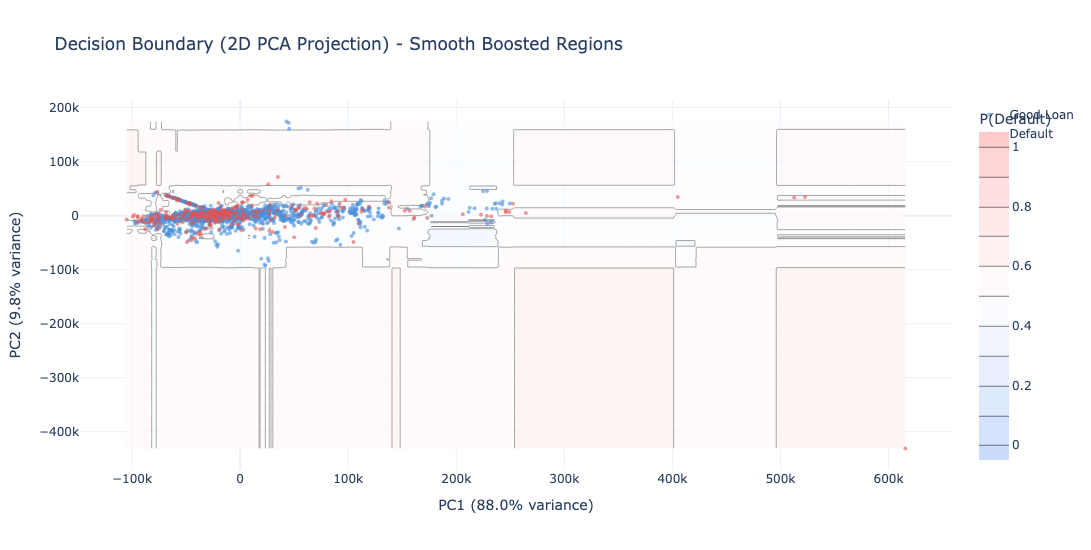

  Saved: outputs/adaboost/decision_boundary_2d.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/adaboost/decision_boundary_2d.html')

In [12]:
from sklearn.decomposition import PCA

# Transform and reduce to 2D
X_train_transformed = prep_tree.fit_transform(X_train)
X_test_transformed = prep_tree.transform(X_test)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_transformed)
X_test_2d = pca.transform(X_test_transformed)

# Train AdaBoost on 2D
ada_2d = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=best_ada.named_steps["clf"].estimator.max_depth,
                                          random_state=RANDOM_STATE),
    n_estimators=best_ada.named_steps["clf"].n_estimators,
    learning_rate=best_ada.named_steps["clf"].learning_rate,
    algorithm="SAMME",
    random_state=RANDOM_STATE,
)
ada_2d.fit(X_train_2d, y_train)

# Create mesh grid — fixed resolution to avoid memory blowup
grid_n = 300
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_n), np.linspace(y_min, y_max, grid_n))
Z = ada_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig_db = go.Figure()
fig_db.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, grid_n), y=np.linspace(y_min, y_max, grid_n), z=Z,
    colorscale=[[0, COLORS["ice"]], [0.5, COLORS["white"]], [1, "#ffcccc"]],
    contours=dict(start=0, end=1, size=0.1),
    showscale=True, colorbar=dict(title="P(Default)"),
    opacity=0.7,
))
for label, color, name in [(0, COLORS["accent"], "Good Loan"), (1, COLORS["red"], "Default")]:
    mask = y_test == label
    fig_db.add_trace(go.Scatter(
        x=X_test_2d[mask, 0], y=X_test_2d[mask, 1],
        mode="markers", name=name,
        marker=dict(color=color, size=4, opacity=0.6),
    ))
fig_db.update_layout(
    title="Decision Boundary (2D PCA Projection) - Smooth Boosted Regions",
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
    height=550, width=700,
)
fig_db.show()
save_chart(fig_db, MODEL_SLUG, "decision_boundary_2d")

---
## 12. Diagnostic Charts


Saving universal charts for AdaBoost:
  Saved: outputs/adaboost/roc_curve.html
  Saved: outputs/adaboost/precision_recall_curve.html
  Saved: outputs/adaboost/confusion_matrix.html
  Saved: outputs/adaboost/threshold_sweep.html


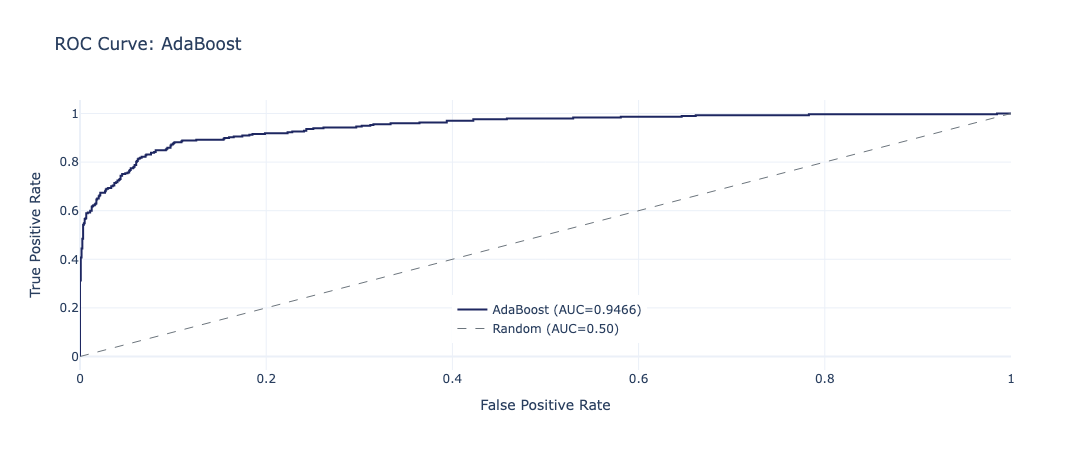

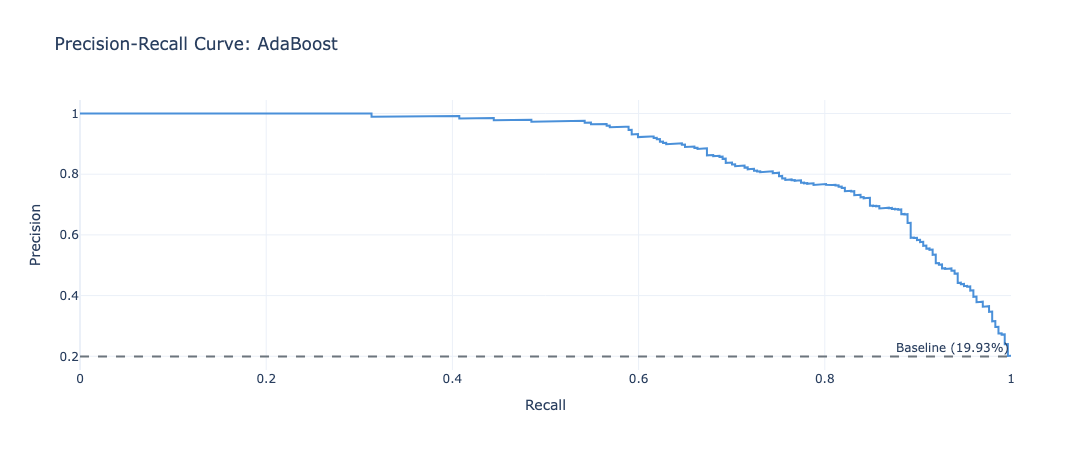

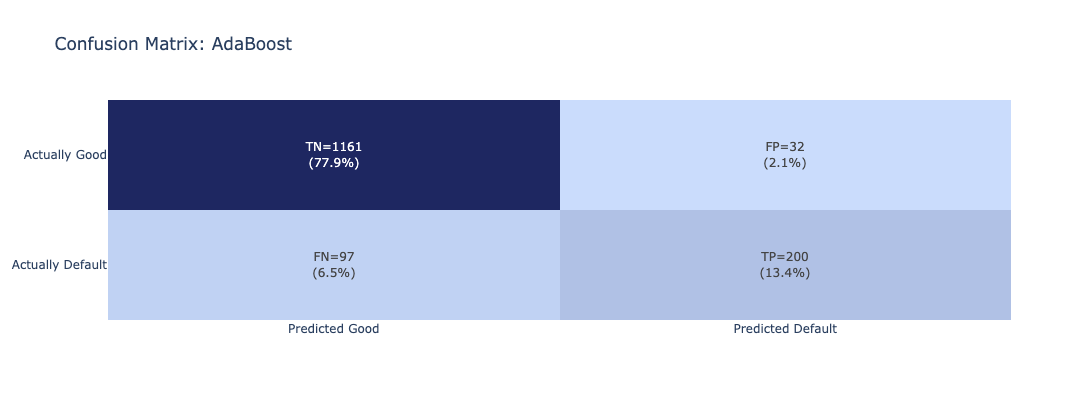

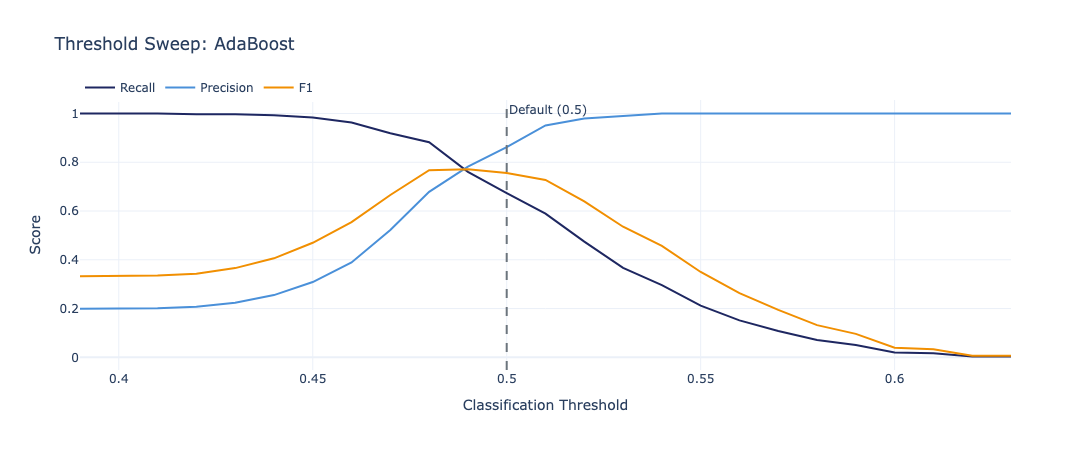

In [13]:
# Generate and save all universal charts
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)

for name, fig in charts.items():
    fig.show()

---
## 13. Summary

### Where AdaBoost Sits on the Tradeoff Spectrum

AdaBoost with decision stumps and balanced sample weighting lands in the **moderate to aggressive** zone, depending on the number of estimators and learning rate. Early stopping (fewer estimators) keeps it moderate; more iterations push it toward aggressive recall.

### Strengths for This Problem
- **Focuses on hard examples**: The exponential loss and weight reweighting make AdaBoost naturally target borrowers that are difficult to classify
- **Interpretable**: Unlike neural networks, boosting still uses decision stumps as weak learners (can inspect feature importance)
- **Good AUC**: The exponential loss minimization leads to strong ranking ability, often with good ROC-AUC
- **Fewer hyperparameters than gradient boosting**: Only n_estimators, learning_rate, and base estimator depth to tune
- **Handles class imbalance**: Sample reweighting naturally emphasizes the minority class

### Limitations for This Problem
- **Sensitive to base estimator quality**: If the weak learner has error rate > 0.5, boosting will fail (the estimator weight becomes negative, flipping predictions)
- **No early stopping** (in sklearn AdaBoost): Must set n_estimators upfront; can overfit with too many iterations
- **Slower than random forest**: Sequential training (each tree depends on the prior one) cannot be parallelized
- **Exponential loss is extreme**: Very sensitive to outliers and mislabeled data, which can hurt calibration
- **Superseded by gradient boosting**: Modern libraries use gradient boosting (sklearn's GradientBoostingClassifier, XGBoost, LightGBM) which is more flexible and often outperforms AdaBoost

### Key Takeaway
AdaBoost is the **original boosting algorithm** and remains historically important. It introduced the idea of training weak learners sequentially with weighted samples. While gradient boosting and XGBoost have largely replaced it in practice, understanding AdaBoost is essential for understanding modern boosting methods. It is especially useful when you need interpretability (decision stumps + feature importance) and want to focus on hard-to-classify examples.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*